In [1]:
#!/Library/Frameworks/Python.framework/Versions/3.11/bin/pip3 install hipopy
import hipopy.hipopy as hp, numpy as np, matplotlib.pyplot as plt,awkward as ak

import mplhep as hep
hep.style.use("CMS")

In [2]:
#f=hp.open("ftTrigger_004162.hipo", "r")
f=hp.open("hadron_pairs_005416_rec_particles.hipo", "r")


In [3]:
f.readBank('REC::Particle')
#f.readBank('RECFT::Particle')

In [62]:
import time
fields = [f'REC::Particle_{a}' for a in "px py pz status pid charge".split()]

mK  = 0.4937
mpi = 0.1396

mLcp = 2.28646
Eb  = 10.6041
thr = 8.7  # your threshold cut in the (10.6 - p) form

masses = []
in_mass_window=0
in_mass_window_kinematics_ok=0
tot_pairs=0

start_time=time.time()
for ievent, event in enumerate(f):

    #if ievent == 10000:
    #    break

    if ievent % 1000 == 0:
        
        print("event#", ievent)
        print("elapsed time", time.time()-start_time)
        print("hadron pairs:", tot_pairs,  ";   in mass window:", in_mass_window,
                    ";   kinematics ok:", in_mass_window_kinematics_ok)
    
    px, py, pz, status, pid, charge = (event[a][0] for a in fields)
    n = len(status)
    if n < 3:
        continue

    px = np.asarray(px); py = np.asarray(py); pz = np.asarray(pz)
    status = np.abs(status); pid = np.asarray(pid); charge = np.asarray(charge)

    p = np.sqrt(px*px + py*py + pz*pz)        
    
    theta=np.atan2(np.hypot(px,py),pz)*180/np.pi

    # FT electron mask: pid==11 and |status| in [1000,2000]
    e_mask = (pid == 11) & (status >= 1000) & (status <= 2000) & (theta>2.5)&(theta<4.5)& ((Eb - p) >= thr)

    if (not np.any(e_mask)) or np.count_nonzero(pid == 11) != 1:
        continue
    #Ee=np.sum(e_mask*np.hypot(p,.000511))

    # hadron candidate masks (adjust pid logic to what you really want)
    # K+: positive charge, FD status in [2000,4000], and pid==321 if you want actual K+
    K_mask  = (status >= 2000) & (status <= 4000) & (charge > 0)  & (pid > 200)&(theta>8.9)

    # pi-: negative charge, FD status in [2000,4000], pid==-211 if you want actual pi-
    pi_mask = (status >= 2000) & (status <= 4000) & (charge < 0)  & (pid <-200)&(theta>8.9)

    if not (np.any(K_mask) and np.any(pi_mask)):
        continue

    # # Slice momenta for candidates
    Kpx, Kpy, Kpz = px[K_mask], py[K_mask], pz[K_mask]
    Ppx, Ppy, Ppz = px[pi_mask], py[pi_mask], pz[pi_mask]

    
    EK = np.sqrt(Kpx*Kpx + Kpy*Kpy + Kpz*Kpz + mK*mK)[:, None]
    EP = np.sqrt(Ppx*Ppx + Ppy*Ppy + Ppz*Ppz + mpi*mpi)[None, :]
    
    dot = (Kpx[:,None]*Ppx[None,:] +
           Kpy[:,None]*Ppy[None,:] +
           Kpz[:,None]*Ppz[None,:])
    
    m2 = (mK*mK + mpi*mpi) + 2.0*(EK*EP - dot)
    np.maximum(m2, 0.0, out=m2)
    m = np.sqrt(m2, out=m2)  # reuse m2 buffer as m

    #also filter out pairs in which there is sufficient missing energy for a lambda c+
    #m2=m2[Eb-EK-EP-Ee>mLcp]

    in_mass_window+=np.count_nonzero((m>1.8)&(m<1.93))
    in_mass_window_kinematics_ok+=np.count_nonzero((m>1.8)&(m<1.93)&\
                                                   (np.hypot(Kpx+Ppx,Kpy+Ppy)<.8)&\
                                                  (Kpz+Ppz<6.5))
    tot_pairs+=m.size
    if m.size>0:
        masses.extend(m.ravel())
    

masses = np.asarray(masses)
print("hadron pairs in mass window:", len(masses[(masses>1.8)&(masses<1.93)]))

event# 0
elapsed time 0.024744033813476562
hadron pairs: 0 ;   in mass window: 0 ;   kinematics ok: 0
event# 1000
elapsed time 10.877826929092407
hadron pairs: 433 ;   in mass window: 4 ;   kinematics ok: 4
event# 2000
elapsed time 21.538987159729004
hadron pairs: 864 ;   in mass window: 13 ;   kinematics ok: 9
event# 3000
elapsed time 31.845802068710327
hadron pairs: 1297 ;   in mass window: 15 ;   kinematics ok: 10
event# 4000
elapsed time 42.21765208244324
hadron pairs: 1757 ;   in mass window: 22 ;   kinematics ok: 15
event# 5000
elapsed time 52.457396030426025
hadron pairs: 2184 ;   in mass window: 24 ;   kinematics ok: 16
event# 6000
elapsed time 62.851678133010864
hadron pairs: 2615 ;   in mass window: 30 ;   kinematics ok: 22
event# 7000
elapsed time 73.15494418144226
hadron pairs: 3051 ;   in mass window: 34 ;   kinematics ok: 25
event# 8000
elapsed time 83.69745397567749
hadron pairs: 3482 ;   in mass window: 40 ;   kinematics ok: 31
event# 9000
elapsed time 94.5238139629364


In [63]:
print(ievent, in_mass_window)

1573744 7896


In [64]:
print(ievent)

1573744


7896 3448


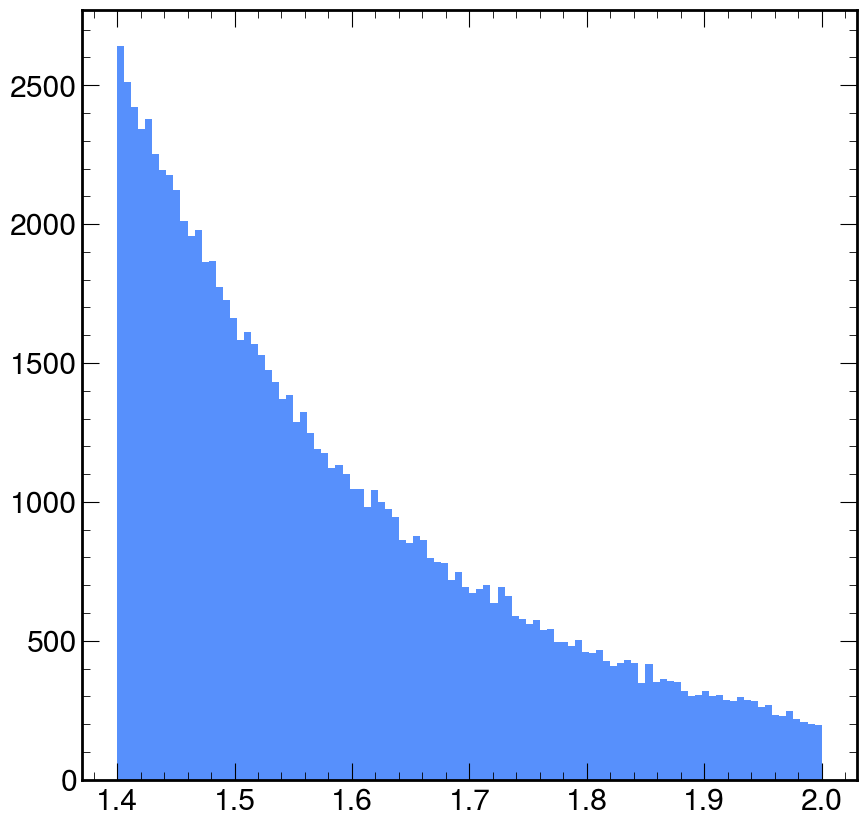

[ 13053.86613199 -72318.35596808 133251.82584625 -81594.40299113]


Text(0, 1, 'events')

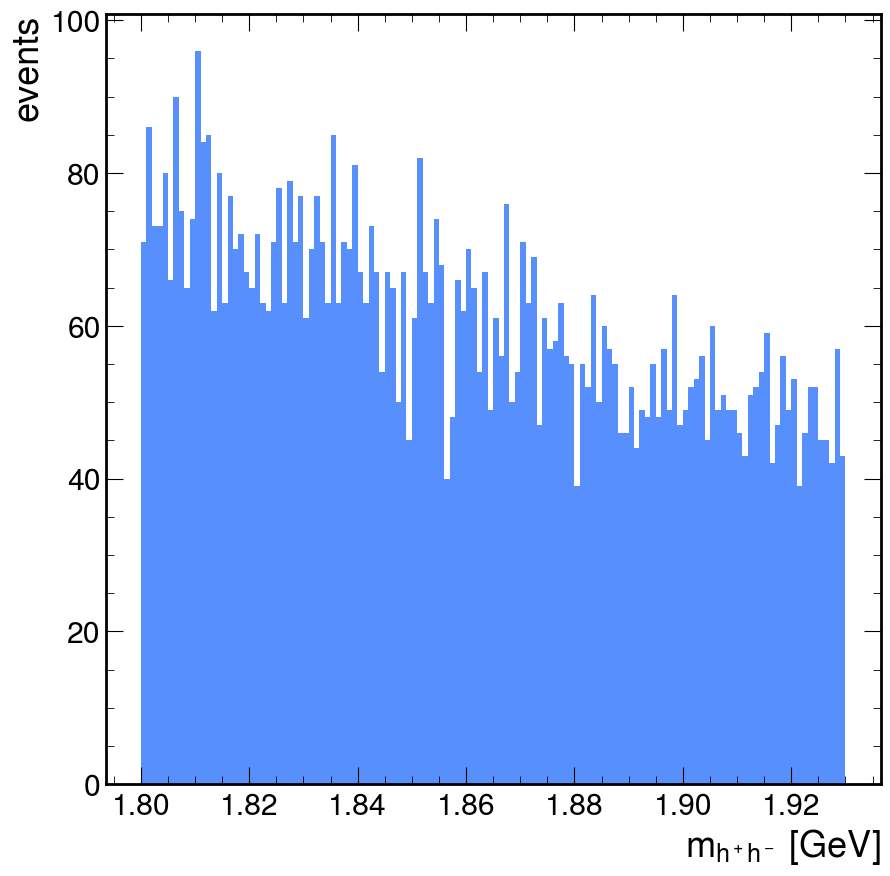

In [69]:
masses=np.array(masses)
plt.hist(masses, range=(1.4, 2.0), bins=100)
print(len(masses[(masses>1.8) &(masses<1.93)]), electrons)
plt.show()
y,x,_=plt.hist(masses, range=(1.8,1.93), bins=130);

x=(x[1:]+x[:-1])/2
print(np.polyfit(x, y, 3))

plt.xlabel('$m_{h^+h^-}$ [GeV]')
plt.ylabel('events')

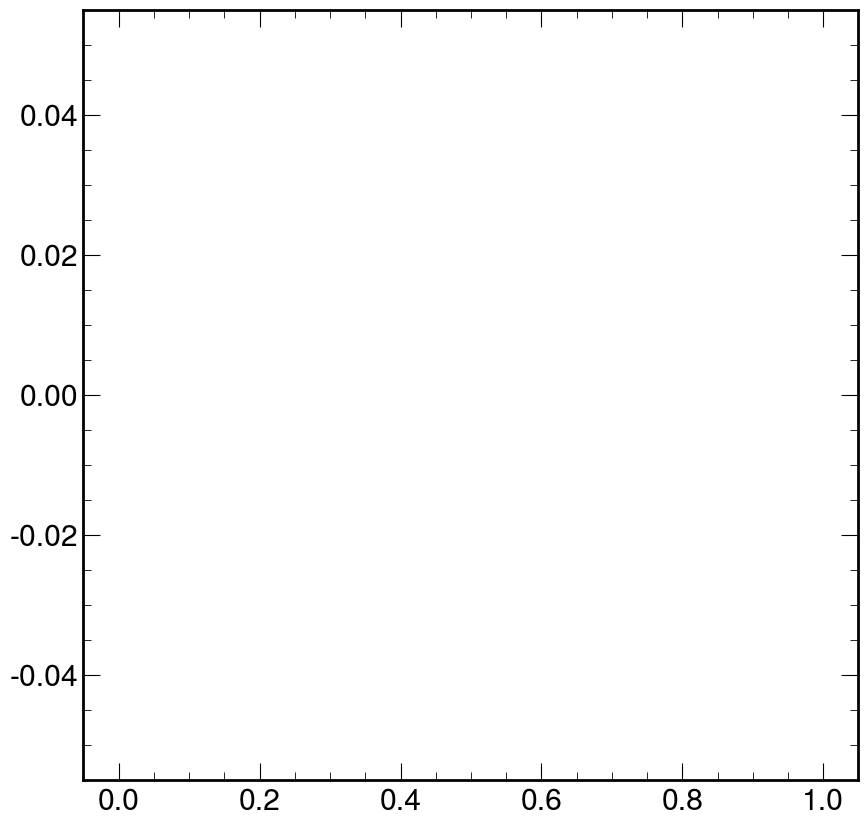

In [15]:
fields = [f'REC::Particle_{a}' for a in "px py pz status pid charge".split()]
theta_e=[]
nu=[]
for ievent, event in enumerate(f):
    
    
    px, py, pz, status, pid, charge = (event[a][0] for a in fields)
    n = len(status)
    if n == 0:
        continue

    px = np.asarray(px); py = np.asarray(py); pz = np.asarray(pz)
    status = np.asarray(status); pid = np.asarray(pid); charge = np.asarray(charge)

    p = np.sqrt(px*px + py*py + pz*pz)

    # FT electron mask: pid==11 and |status| in [1000,2000]
    e_mask = (pid == 11) & (status >= 1110) & (status < 2000)
    theta_e.extend(((np.atan2(np.hypot(px,py),pz)*180/np.pi)[e_mask]))
    if ievent==1000:
        break
    nu.extend(10.6-np.sqrt(px**2+py**2+pz**2)[e_mask])
plt.hist(theta_e, bins=100)
plt.show()

(array([ 23.,  25.,  31.,  31.,  34.,  33.,  28.,  21.,  42.,  32.,  28.,
         31.,  36.,  36.,  29.,  35.,  37.,  42.,  34.,  33.,  30.,  52.,
         45.,  32.,  43.,  48.,  37.,  38.,  42.,  40.,  42.,  60.,  61.,
         43.,  61.,  69.,  45.,  69.,  69.,  74.,  77.,  70.,  75.,  77.,
         89.,  94.,  84.,  80.,  81., 120., 102.,  96., 109., 118., 121.,
        107., 140., 132., 151., 140., 148., 169., 173., 191., 191., 214.,
        250., 347., 382., 445., 232.,  14.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 8.7  ,  8.723,  8.746,  8.769,  8.792,  8.815,  8.838,  8.861,
         8.884,  8.907,  8.93 ,  8.953,  8.976,  8.999,  9.022,  9.045,
         9.068,  9.091,  9.114,  9.137,  9.16 ,  9.183,  9.206,  9.229,
         9.252,  9.275,  9.298,  9.321,  9.344,  9.367,  9.39 ,  9.413,
         9.436,  9.459,  9.482

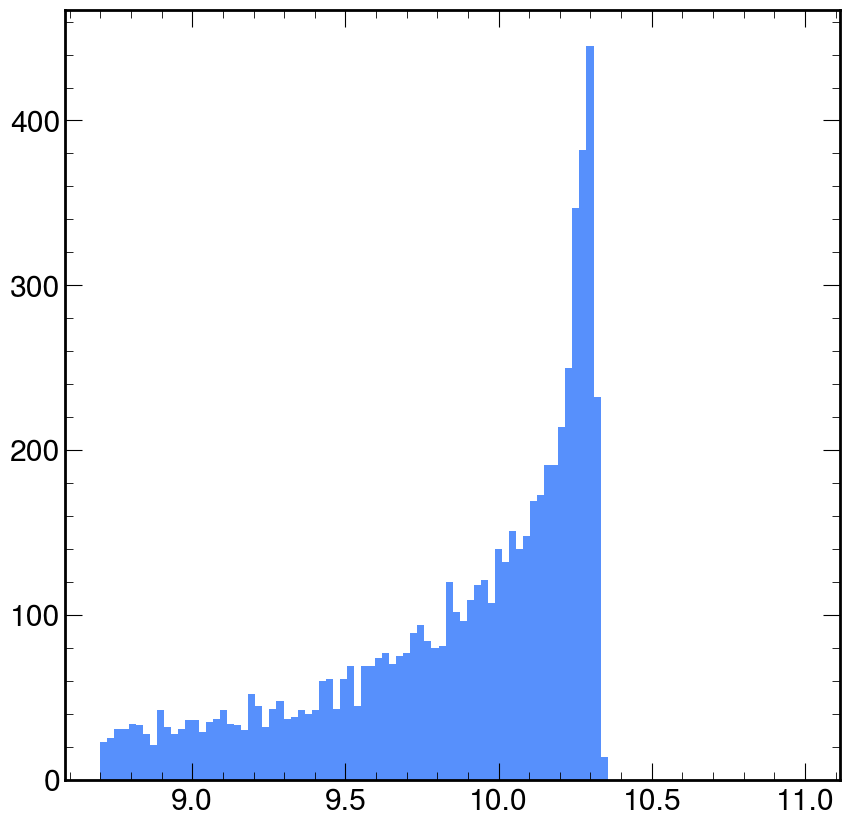

In [33]:
plt.hist(nu, bins=100, range=(8.7, 11))

In [18]:
fields = [f'REC::Particle_{a}' for a in "px py pz status pid charge".split()]

mK  = 0.4937
mpi = 0.1396
Eb  = 10.6
thr = 8.7  # your threshold cut in the (10.6 - p) form

masses = []

for ievent, event in enumerate(f):
    

    if ievent % 10000 == 0:
        print(ievent)
        m=np.array(masses)
        print("hadron pairs in mass window:", len(m[(m>1.8)&(m<1.93)]))
    
    px, py, pz, status, pid, charge = (event[a][0] for a in fields)
    n = len(status)
    if n == 0:
        continue

    px = np.asarray(px); py = np.asarray(py); pz = np.asarray(pz)
    status = np.abs(status); pid = np.asarray(pid); charge = np.asarray(charge)

    p = np.sqrt(px*px + py*py + pz*pz)

    charge_mask= np.abs(charge)!=0

    theta =180/np.pi*np.arctan2(np.hypot(px,py),pz)

    #theta_mask=
    
    e_mask = (pid == 11) & (status >= 1000) & (status <= 2000)

    if not np.any(e_mask):
        continue

    

    # your cut: if (10.6 - p) < 8.7: continue  <=>  p > 1.9
    # keep electrons with p <= (10.6 - 8.7) = 1.9 (as you wrote it)
    # (If you actually meant "electron energy above threshold", you may want the opposite!)
    e_keep = e_mask & ((Eb - p) >= thr)

    if not np.any(e_keep):
        continue

    # hadron candidate masks (adjust pid logic to what you really want)
    # K+: positive charge, FD status in [2000,4000], and pid==321 if you want actual K+
    K_mask  = (status >= 2000) & (status <= 4000) & (charge > 0)  & (pid > 200)

    # pi-: negative charge, FD status in [2000,4000], pid==-211 if you want actual pi-
    pi_mask = (status >= 2000) & (status <= 4000) & (charge < 0)  & (pid <-200)

    if not (np.any(K_mask) and np.any(pi_mask)):
        continue

    # Slice momenta for candidates
    Kpx, Kpy, Kpz = px[K_mask], py[K_mask], pz[K_mask]
    Ppx, Ppy, Ppz = px[pi_mask], py[pi_mask], pz[pi_mask]

    EK = np.sqrt(Kpx*Kpx + Kpy*Kpy + Kpz*Kpz + mK*mK)
    EP = np.sqrt(Ppx*Ppx + Ppy*Ppy + Ppz*Ppz + mpi*mpi)

    # Broadcast to all K+pi- pairs: shapes (nK,1) and (1,nP)
    EK = EK[:, None];  EP = EP[None, :]
    Kpx = Kpx[:, None]; Kpy = Kpy[:, None]; Kpz = Kpz[:, None]
    Ppx = Ppx[None, :]; Ppy = Ppy[None, :]; Ppz = Ppz[None, :]

    E  = EK + EP
    pxs = Kpx + Ppx
    pys = Kpy + Ppy
    pzs = Kpz + Ppz

    m2 = E*E - (pxs*pxs + pys*pys + pzs*pzs)

    # numerical safety
    m2 = np.maximum(m2, 0.0)

    masses.extend(np.sqrt(m2).ravel())

masses = np.asarray(masses)
print("pairs:", masses.size)
print("hadron pairs in mass window:", len(masses[(masses>1.8)&(masses<1.93)]))


0
hadron pairs in mass window: 0
10000
hadron pairs in mass window: 66


KeyboardInterrupt: 

In [3]:
f.readBank("REC::ForwardTagger")
print(f.getNamesAndTypes("REC::ForwardTagger"))
# energies=[]
# for ievent, event in enumerate(f):
#     if ievent ==10000:
#         break
#     energies.extend(np.array(event['FT::particles_energy'][0]))
#     charges=event['FT::particles_charge'][0]
#     vxs=event['FT::particles_vx'][0]
#     vys=event['FT::particles_vy'][0]
#     vzs=event['FT::particles_vz'][0]
#     cxs=event['FT::particles_cx'][0]
#     cys=event['FT::particles_cy'][0]
#     czs=event['FT::particles_cz'][0]

{'index': 'S', 'pindex': 'S', 'detector': 'B', 'layer': 'B', 'energy': 'F', 'time': 'F', 'path': 'F', 'chi2': 'F', 'x': 'F', 'y': 'F', 'z': 'F', 'dx': 'F', 'dy': 'F', 'radius': 'F', 'size': 'S', 'status': 'S'}


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 

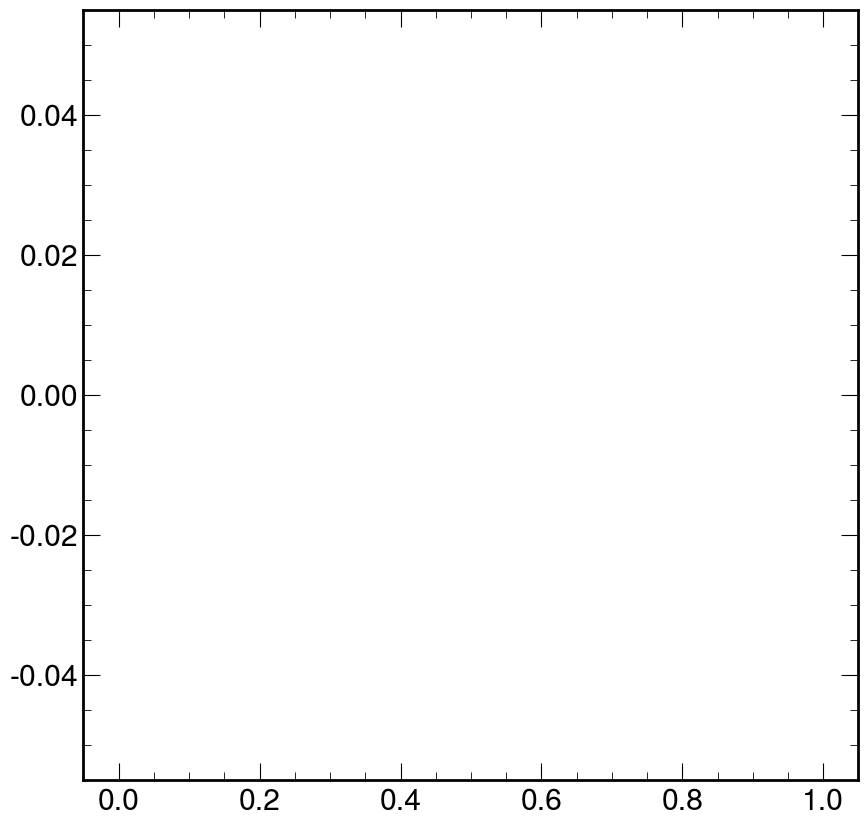

In [51]:
plt.hist(10.6-np.array(energies), bins=100)
    

In [4]:
f.getBanks()

['ALRTDC::Clusters',
 'ALRTDC::Hits',
 'ALRTDC::KFTrack',
 'ALRTDC::MC',
 'ALRTDC::PreClusters',
 'ALRTDC::Track',
 'BAND::adc',
 'BAND::hits',
 'BAND::laser',
 'BAND::rawhits',
 'BAND::tdc',
 'BMT::Clusters',
 'BMT::Crosses',
 'BMT::Hits',
 'BMT::adc',
 'BMTRec::Clusters',
 'BMTRec::Crosses',
 'BMTRec::Hits',
 'BMTRec::LayerEffs',
 'BST::Clusters',
 'BST::Crosses',
 'BST::Hits',
 'BST::adc',
 'BSTRec::Clusters',
 'BSTRec::Crosses',
 'BSTRec::Hits',
 'BSTRec::LayerEffs',
 'CND::adc',
 'CND::clusters',
 'CND::hits',
 'CND::tdc',
 'COAT::config',
 'CTOF::adc',
 'CTOF::clusters',
 'CTOF::hits',
 'CTOF::rawhits',
 'CTOF::tdc',
 'CVT::KFTrajectory',
 'CVT::SeedClusters',
 'CVT::Seeds',
 'CVT::Tracks',
 'CVT::Trajectory',
 'CVT::UTracks',
 'CVTRec::CosmicSeeds',
 'CVTRec::Cosmics',
 'CVTRec::KFTrajectory',
 'CVTRec::SeedClusters',
 'CVTRec::Seeds',
 'CVTRec::TrackCovMat',
 'CVTRec::Tracks',
 'CVTRec::Trajectory',
 'CVTRec::UTracks',
 'DC::doca',
 'DC::jitter',
 'DC::tdc',
 'DETECTOR::ccpb',


In [16]:
import time
fields = [f'REC::Particle_{a}' for a in "px py pz status pid charge".split()]

mK  = 0.4937
mpi = 0.1396

mLcp = 2.28646
Eb  = 10.6041
thr = 8.7  # your threshold cut in the (10.6 - p) form

masses = []

tot=0

start_time=time.time()
for ievent, event in enumerate(f):


    #if ievent == 10000:
    #    break

    if ievent % 1000 == 0:
        
        print("event#", ievent)
        print("elapsed time", time.time()-start_time)
        print("hadron pairs:", tot_pairs,  ";   in mass window:", in_mass_window,
                    ";   kinematics ok:", in_mass_window_kinematics_ok)
    
    px, py, pz, status, pid, charge = (event[a][0] for a in fields)
    n = len(status)
    if n < 3:
        continue

    px = np.asarray(px); py = np.asarray(py); pz = np.asarray(pz)
    status = np.abs(status); pid = np.asarray(pid); charge = np.asarray(charge)

    p = np.sqrt(px*px + py*py + pz*pz)        
    
    theta=np.atan2(np.hypot(px,py),pz)*180/np.pi

    # FT electron mask: pid==11 and |status| in [1000,2000]
    e_mask = (pid == 11) & (status >= 1000) & (status <= 2000) & (theta>2.5)&(theta<4.5)& ((Eb - p) >= thr)

    if (not np.any(e_mask)) or np.count_nonzero(pid == 11) != 1:
        continue
    #Ee=np.sum(e_mask*np.hypot(p,.000511))

    # hadron candidate masks (adjust pid logic to what you really want)
    # K+: positive charge, FD status in [2000,4000], and pid==321 if you want actual K+
    K_mask  = (status >= 2000) & (status <= 4000) & (charge > 0)  & (pid > 200)&(theta>8.9)

    # pi-: negative charge, FD status in [2000,4000], pid==-211 if you want actual pi-
    pi_mask = (status >= 2000) & (status <= 4000) & (charge < 0)  & (pid <-200)&(theta>8.9)

    if not (np.any(K_mask) and np.any(pi_mask)):
        continue

    # # Slice momenta for candidates
    Kpx, Kpy, Kpz = px[K_mask], py[K_mask], pz[K_mask]
    Ppx, Ppy, Ppz = px[pi_mask], py[pi_mask], pz[pi_mask]

    
    EK = np.sqrt(Kpx*Kpx + Kpy*Kpy + Kpz*Kpz + mK*mK)[:, None]
    EP = np.sqrt(Ppx*Ppx + Ppy*Ppy + Ppz*Ppz + mpi*mpi)[None, :]
    
    dot = (Kpx[:,None]*Ppx[None,:] +
           Kpy[:,None]*Ppy[None,:] +
           Kpz[:,None]*Ppz[None,:])
    
    m2 = (mK*mK + mpi*mpi) + 2.0*(EK*EP - dot)
    np.maximum(m2, 0.0, out=m2)
    m = np.sqrt(m2, out=m2)  # reuse m2 buffer as m

    #also filter out pairs in which there is sufficient missing energy for a lambda c+
    #m2=m2[Eb-EK-EP-Ee>mLcp]

    in_mass_window+=np.count_nonzero((m>1.8)&(m<1.93))
    in_mass_window_kinematics_ok+=np.count_nonzero((m>1.8)&(m<1.93)&\
                                                   (np.hypot(Kpx+Ppx,Kpy+Ppy)<.8)&\
                                                  (Kpz+Ppz<6.5))
    tot_pairs+=m.size
    if m.size>0:
        masses.extend(m.ravel())
    

masses = np.asarray(masses)
print("hadron pairs in mass window:", len(masses[(masses>1.8)&(masses<1.93)]))

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
hadron pairs in mass window: 0


In [17]:
!ls hadron_pairs_005416*

hadron_pairs_005416_rec_particles.hipo


In [20]:
import time
fields = [f'REC::Particle_{a}' for a in "px py pz status pid charge".split()]

mK  = 0.4937
mpi = 0.1396

mLcp = 2.28646
Eb  = 10.6041
thr = 8.7  # your threshold cut in the (10.6 - p) form

masses = []
in_mass_window=0
in_mass_window_kinematics_ok=0
tot_pairs=0

start_time=time.time()
for ievent, event in enumerate(f):

    #if ievent == 10000:
    #    break

    if ievent % 1000 == 0:
        
        print("event#", ievent)
        print("elapsed time", time.time()-start_time)
        print("hadron pairs:", tot_pairs)
    
    px, py, pz, status, pid, charge = (event[a][0] for a in fields)
    n = len(status)
    if n < 3:
        continue

    px = np.asarray(px); py = np.asarray(py); pz = np.asarray(pz)
    status = np.abs(status); pid = np.asarray(pid); charge = np.asarray(charge)

    p = np.sqrt(px*px + py*py + pz*pz)        
    
    #theta=np.atan2(np.hypot(px,py),pz)*180/np.pi

    # FT electron mask: pid==11 and |status| in [1000,2000]
    e_mask = (pid == 11) & (status >= 1000) & (status <= 2000) & ((Eb - p) >= thr)

    if (not np.any(e_mask)) or np.count_nonzero(pid == 11) != 1:
        continue
    #Ee=np.sum(e_mask*np.hypot(p,.000511))

    # hadron candidate masks (adjust pid logic to what you really want)
    # K+: positive charge, FD status in [2000,4000], and pid==321 if you want actual K+
    h_mask  = (status >= 2000) & (status <= 4000) & (charge != 0)  & (abs(pid) > 200)

    if not (np.count_nonzero(h_mask)>=2):
        continue
    tot_pairs+=1
    

event# 0
elapsed time 0.026988983154296875
hadron pairs: 0
event# 1000
elapsed time 11.559613943099976
hadron pairs: 422
event# 2000
elapsed time 23.09563708305359
hadron pairs: 884
event# 3000
elapsed time 35.19470286369324
hadron pairs: 1333
event# 4000
elapsed time 46.82402014732361
hadron pairs: 1770
event# 5000
elapsed time 58.62280607223511
hadron pairs: 2210
event# 6000
elapsed time 70.29412198066711
hadron pairs: 2636
event# 7000
elapsed time 81.8874261379242
hadron pairs: 3080
event# 8000
elapsed time 93.51299500465393
hadron pairs: 3504
event# 9000
elapsed time 105.17149806022644
hadron pairs: 3946
event# 10000
elapsed time 116.98260498046875
hadron pairs: 4376
event# 11000
elapsed time 129.1560778617859
hadron pairs: 4813
event# 12000
elapsed time 141.0287618637085
hadron pairs: 5252
event# 13000
elapsed time 152.74008297920227
hadron pairs: 5693
event# 14000
elapsed time 164.81406903266907
hadron pairs: 6118
event# 15000
elapsed time 177.0970640182495
hadron pairs: 6545
eve

KeyboardInterrupt: 